# Hizli Test EDA

Tek dosya / ~100k satir ornek. Profesyonel analiz: `03_eda_cicids2018.ipynb` veya `04_eda_ciciot2023.ipynb`.


Yuklenen IoT Dosyasi: Backdoor_Malware.pcap.csv



--- Veri Temizligi ---
Ham boyut: (3218, 39)
Temizlenmis boyut: (3218, 40)
Silinen satir: 0

Eksik degeri en yuksek ilk 10 sutun:
                 missing_count  missing_ratio
Header_Length                0            0.0
Protocol Type                0            0.0
Time_To_Live                 0            0.0
Rate                         0            0.0
fin_flag_number              0            0.0
syn_flag_number              0            0.0
rst_flag_number              0            0.0
psh_flag_number              0            0.0
ack_flag_number              0            0.0
ece_flag_number              0            0.0

--- Sinif Dengesi ---
label
Backdoor_Malware    3218
Name: count, dtype: int64

Binary dagilim:
label
Attack    3218
Name: count, dtype: int64

--- Outlier Analizi (IQR) ---
Max             0.209136
Variance        0.178993
AVG             0.177129
Tot sum         0.177129
Tot size        0.177129
Std             0.168738
Rate            0.139838
Min          

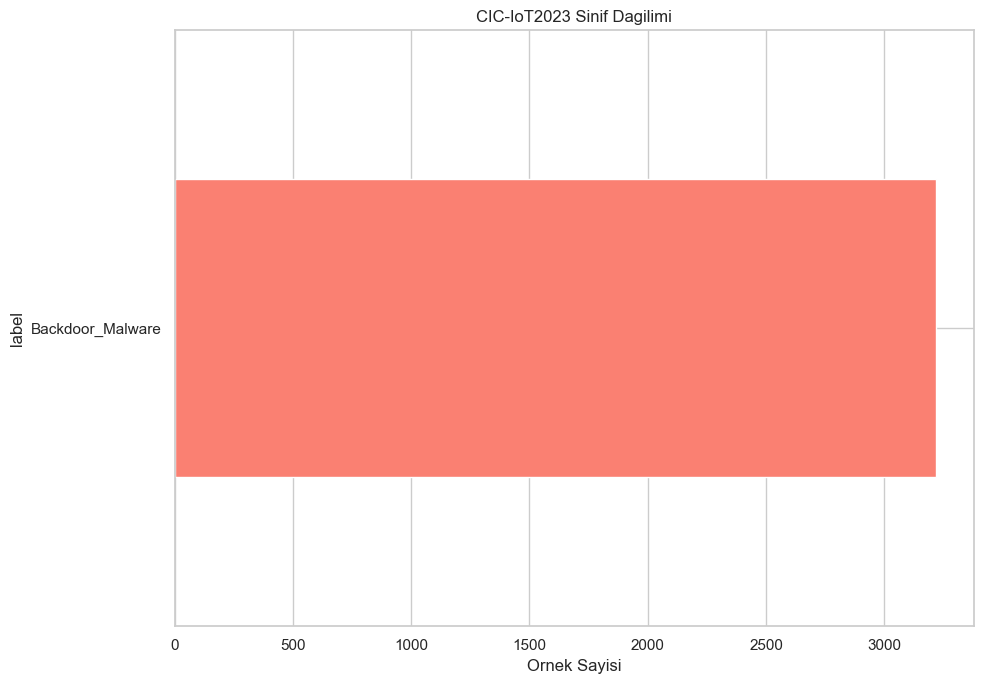

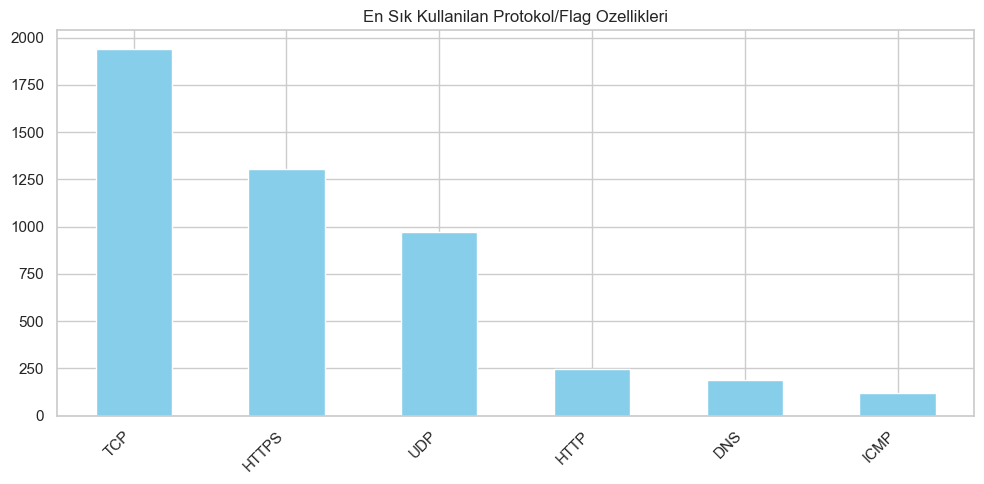

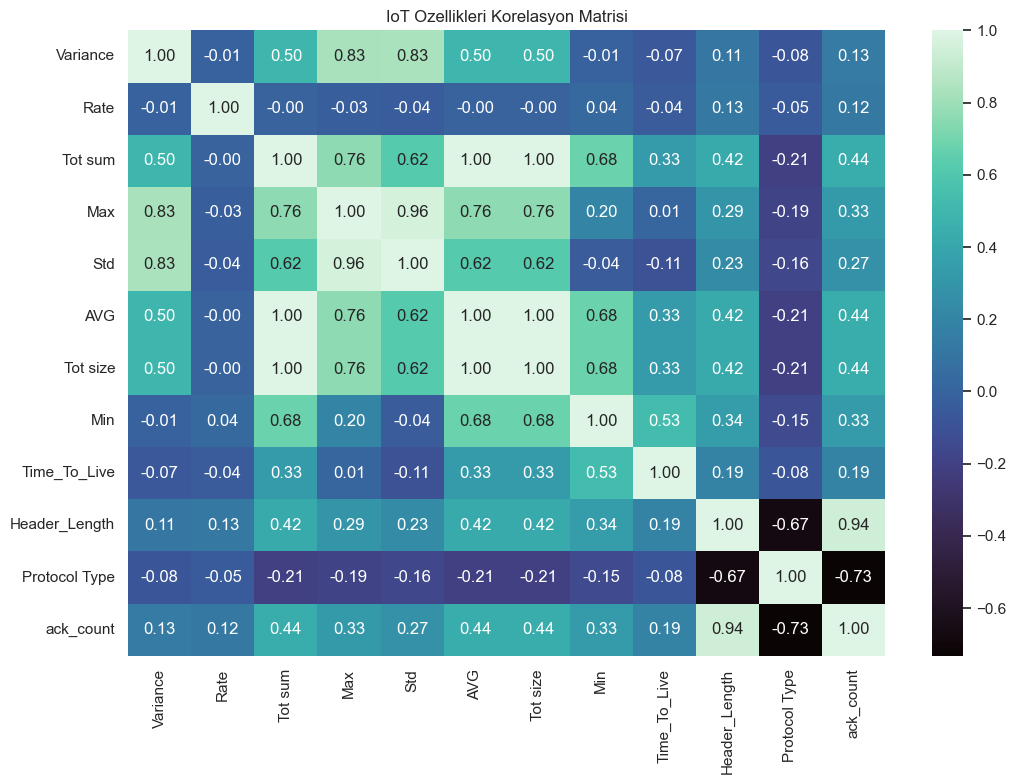

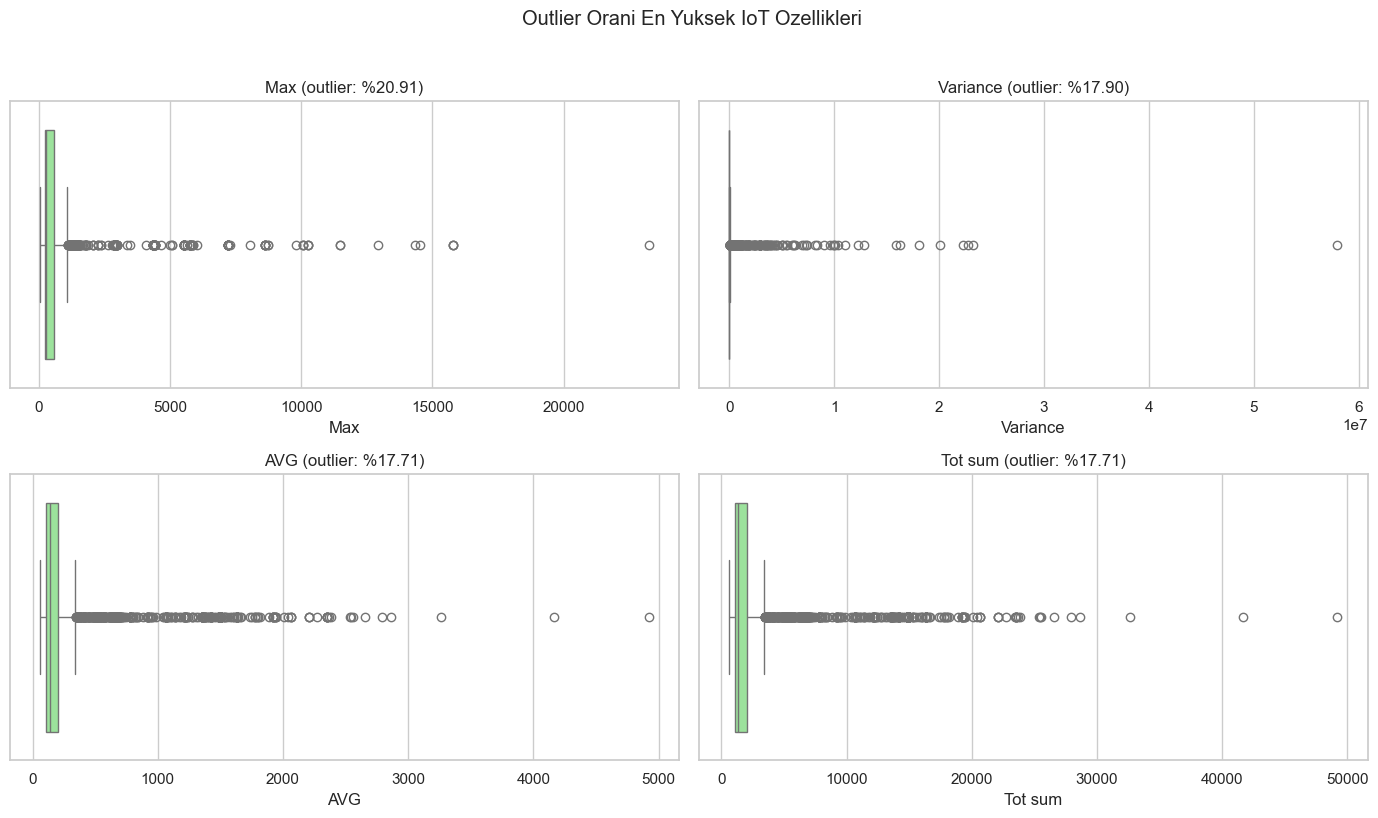

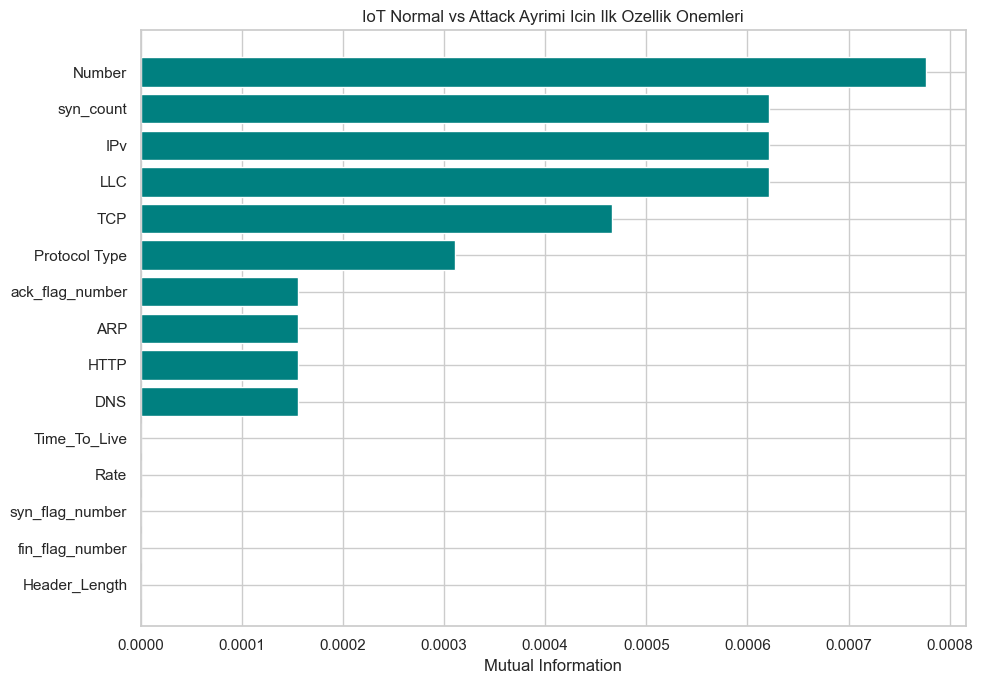

In [1]:
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

RANDOM_STATE = 42
MAX_ROWS = 100_000
TOP_CORR_FEATURES = 12
TOP_OUTLIER_FEATURES = 10
TOP_IMPORTANCE_FEATURES = 15
sns.set(style="whitegrid")


def find_project_root(start_path: Path) -> Path:
    """Find project root by searching configs/datasets.yaml.

    Args:
        start_path: Current working directory path.

    Returns:
        Project root path.
    """
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "configs" / "datasets.yaml").exists():
            return candidate
    raise FileNotFoundError("Project root bulunamadi.")


def resolve_iot_csv(raw_dir: Path) -> Path:
    """Resolve one IoT CSV file from raw folder.

    Args:
        raw_dir: Raw IoT directory.

    Returns:
        Selected CSV path.
    """
    csv_files = sorted(raw_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"IoT CSV dosyasi bulunamadi: {raw_dir}")
    return csv_files[0]


def load_iot_sample(root_dir: Path) -> Tuple[pd.DataFrame, Path]:
    """Load sampled IoT dataframe and selected file path.

    Args:
        root_dir: Project root path.

    Returns:
        Sampled dataframe and selected CSV path.
    """
    raw_dir = root_dir / "data" / "raw" / "ciciot2023"
    csv_path = resolve_iot_csv(raw_dir)
    print(f"Yuklenen IoT Dosyasi: {csv_path.name}")

    df_local = pd.read_csv(csv_path)
    sample_size = min(MAX_ROWS, len(df_local))
    return df_local.sample(n=sample_size, random_state=RANDOM_STATE), csv_path


def resolve_label_column(df_in: pd.DataFrame, csv_path: Path) -> Tuple[pd.DataFrame, str]:
    """Resolve label column robustly for IoT dataset.

    Args:
        df_in: Input dataframe.
        csv_path: Source CSV path.

    Returns:
        Dataframe with label column and label column name.
    """
    df_copy = df_in.copy()
    lower_to_original = {c.lower(): c for c in df_copy.columns}

    for candidate in ["label", "attack", "target", "class"]:
        if candidate in lower_to_original:
            return df_copy, lower_to_original[candidate]

    derived_label = csv_path.stem.replace(".pcap", "")
    df_copy["label"] = derived_label
    return df_copy, "label"


def clean_dataframe(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Clean dataframe and produce missing-value report.

    Args:
        df_in: Raw dataframe.

    Returns:
        Tuple of cleaned dataframe and missing report.
    """
    df_copy = df_in.copy()
    df_copy.columns = df_copy.columns.str.strip()
    df_copy = df_copy.replace([np.inf, -np.inf], np.nan)

    missing = (
        df_copy.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame()
    )
    missing["missing_ratio"] = missing["missing_count"] / len(df_copy)
    return df_copy.dropna(), missing


def calculate_outlier_ratios(df_in: pd.DataFrame) -> pd.Series:
    """Calculate outlier ratio per numeric feature using IQR.

    Args:
        df_in: Input dataframe.

    Returns:
        Outlier ratio series sorted descending.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    q1 = numeric_df.quantile(0.25)
    q3 = numeric_df.quantile(0.75)
    iqr = q3 - q1

    valid_cols = iqr[iqr > 0].index
    if len(valid_cols) == 0:
        return pd.Series(dtype=float)

    lower = q1[valid_cols] - 1.5 * iqr[valid_cols]
    upper = q3[valid_cols] + 1.5 * iqr[valid_cols]
    outlier_mask = (numeric_df[valid_cols] < lower) | (numeric_df[valid_cols] > upper)
    return outlier_mask.mean().sort_values(ascending=False)


def compute_feature_importance(df_in: pd.DataFrame, binary_target: pd.Series) -> pd.Series:
    """Compute first-look feature separability with mutual information.

    Args:
        df_in: Input dataframe.
        binary_target: Binary target series.

    Returns:
        Sorted MI score series.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    if numeric_df.empty:
        return pd.Series(dtype=float)

    numeric_filled = numeric_df.fillna(numeric_df.median(numeric_only=True))
    scores = mutual_info_classif(
        numeric_filled,
        binary_target,
        random_state=RANDOM_STATE,
        discrete_features=False,
    )
    return pd.Series(scores, index=numeric_filled.columns).sort_values(ascending=False)


def plot_class_distribution(df_in: pd.DataFrame, label_col: str) -> None:
    """Plot class distribution.

    Args:
        df_in: Input dataframe.
        label_col: Label column name.
    """
    plt.figure(figsize=(10, 7))
    counts = df_in[label_col].value_counts().sort_values(ascending=True)
    counts.plot(kind="barh", color="salmon")
    plt.title("CIC-IoT2023 Sinif Dagilimi")
    plt.xlabel("Ornek Sayisi")
    plt.tight_layout()
    plt.show()


def plot_protocol_overview(df_in: pd.DataFrame) -> None:
    """Plot protocol-related feature sums.

    Args:
        df_in: Input dataframe.
    """
    proto_cols = [
        c for c in df_in.columns if any(p in c.lower() for p in ["tcp", "udp", "icmp", "dns", "http"])
    ]
    if not proto_cols:
        print("Uyari: Protokol ile ilgili sutun bulunamadi.")
        return

    proto_sums = df_in[proto_cols].select_dtypes(include=[np.number]).sum().sort_values(ascending=False)
    top_proto = proto_sums.head(8)
    plt.figure(figsize=(10, 5))
    top_proto.plot(kind="bar", color="skyblue")
    plt.title("En Sık Kullanilan Protokol/Flag Ozellikleri")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df_in: pd.DataFrame) -> None:
    """Plot correlation heatmap using top variance features.

    Args:
        df_in: Input dataframe.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    if numeric_df.shape[1] < 2:
        print("Uyari: Korelasyon icin yeterli sayisal feature yok.")
        return

    top_features = (
        numeric_df.var().sort_values(ascending=False).head(TOP_CORR_FEATURES).index
    )
    plt.figure(figsize=(11, 8))
    sns.heatmap(df_in[top_features].corr(), annot=True, cmap="mako", fmt=".2f")
    plt.title("IoT Ozellikleri Korelasyon Matrisi")
    plt.tight_layout()
    plt.show()


def plot_top_outlier_features(df_in: pd.DataFrame, outlier_ratios: pd.Series) -> None:
    """Plot boxplots for top outlier-heavy features.

    Args:
        df_in: Input dataframe.
        outlier_ratios: Outlier ratio series.
    """
    if outlier_ratios.empty:
        print("Uyari: Outlier analizi icin uygun feature yok.")
        return

    top_cols = outlier_ratios.head(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes_flat = axes.flatten()
    for idx, col in enumerate(top_cols):
        sns.boxplot(x=df_in[col], ax=axes_flat[idx], color="lightgreen")
        ratio = outlier_ratios[col] * 100
        axes_flat[idx].set_title(f"{col} (outlier: %{ratio:.2f})")

    for idx in range(len(top_cols), len(axes_flat)):
        axes_flat[idx].axis("off")

    plt.suptitle("Outlier Orani En Yuksek IoT Ozellikleri", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importance_scores: pd.Series) -> None:
    """Plot top feature importance snapshot.

    Args:
        importance_scores: MI score series.
    """
    if importance_scores.empty:
        print("Uyari: Feature importance hesaplanamadi.")
        return

    top_scores = importance_scores.head(TOP_IMPORTANCE_FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    plt.barh(top_scores.index, top_scores.values, color="teal")
    plt.title("IoT Normal vs Attack Ayrimi Icin Ilk Ozellik Onemleri")
    plt.xlabel("Mutual Information")
    plt.tight_layout()
    plt.show()


project_root = find_project_root(Path.cwd())
iot_raw_df, iot_csv_path = load_iot_sample(project_root)
iot_labeled_df, label_col = resolve_label_column(iot_raw_df, iot_csv_path)
iot_df, missing_report = clean_dataframe(iot_labeled_df)

binary_target = (iot_df[label_col].astype(str).str.lower() != "normal").astype(int)
outlier_ratios = calculate_outlier_ratios(iot_df)
importance_scores = compute_feature_importance(iot_df, binary_target)

print("\n--- Veri Temizligi ---")
print(f"Ham boyut: {iot_raw_df.shape}")
print(f"Temizlenmis boyut: {iot_df.shape}")
print(f"Silinen satir: {len(iot_raw_df) - len(iot_df)}")
print("\nEksik degeri en yuksek ilk 10 sutun:")
print(missing_report.head(10))

print("\n--- Sinif Dengesi ---")
print(iot_df[label_col].value_counts().head(15))
print("\nBinary dagilim:")
print(binary_target.value_counts().rename(index={0: "Normal", 1: "Attack"}))

print("\n--- Outlier Analizi (IQR) ---")
print(outlier_ratios.head(TOP_OUTLIER_FEATURES))

print("\n--- Ayrim Gucu Yuksek Ozellikler ---")
print(importance_scores.head(TOP_IMPORTANCE_FEATURES))

plot_class_distribution(iot_df, label_col=label_col)
plot_protocol_overview(iot_df)
plot_correlation_heatmap(iot_df)
plot_top_outlier_features(iot_df, outlier_ratios)
plot_feature_importance(importance_scores)
